In [2]:
import gymnasium as gym
import numpy as np 
import time
import matplotlib.pyplot as plt
from IPython import display
import math

#### Seeding the env

In [3]:
env = gym.make('CartPole-v1', render_mode='rgb_array').env
env.np_random = np.random.default_rng(123)
env.action_space.seed(123)
env.observation_space.seed(123)

[123]

In [4]:
# in this case now we have only 2 actions 0 --> left, 1 --> right
num_actions = env.action_space.n
print(num_actions)

2


In [5]:
states_cart = env.observation_space
print(states_cart)
# we have intervals : (cart position, cart velocity, pole angle, pole velocity)
# each episode finishes if the cart leaves (-2.4,2.4) or if the pole is not in the range (-0.2095, 0.2095)
# the reward is +1 or -1 for eevery step
# we have then 4 values for each state
print(env.spec.reward_threshold, env.spec.max_episode_steps)

Box([-4.8000002e+00 -3.4028235e+38 -4.1887903e-01 -3.4028235e+38], [4.8000002e+00 3.4028235e+38 4.1887903e-01 3.4028235e+38], (4,), float32)
475.0 None


In [6]:
# defining our parameters these are the most used in this scenario
learning_rate = 0.1
discount_factor = 0.95

In [7]:
state_space = 4 # number of states
action_space = 2 # number of possible actions
num_bins = 50
state_space_bins = [num_bins]*state_space
print(state_space_bins)
qu = np.zeros([num_bins]*state_space+[action_space])

[50, 50, 50, 50]


In [8]:
# once we have discrete states, now we need a function to know in wich class we are
def discrete(state):
    state_bins = []
    for i in range(state_space):
        state_bins.append(int((state[i]+2.4)/4.8*num_bins))
        # to ensure we are in the correct range
        state_bins[i] = max(0, min(num_bins-1, state_bins[i]))
    return tuple(state_bins)

In [14]:
episodes = 100000
total_reward = 0
prior_reward = 0
initial_epsilon = 1.0 
final_epsilon = 0.1  
epsilon_decay = 0.9995
epsilon = initial_epsilon
training_reward = []
average_rew = []
for i in range(episodes):
    done = False
    state = discrete(env.reset()[0])
    sum_reward = 0
    while done==False:
        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(qu[state])
            
        next_state, reward, done, truncated, info2 = env.step(action)
        sum_reward = sum_reward + reward
        next_state = discrete(next_state)
        # we use the epsilon greedy decay strategy
        qu[state][action] = qu[state][action] + learning_rate*(reward + discount_factor*max(qu[next_state])-qu[state][action])
        state = next_state
        if truncated:
            done = True
    # we update the epsilon only if the reward of the actual episode is better than the last one
    # by doing this we can ensure that more random states are done, i took this from an article in medium
    if epsilon > 0.05:
        if sum_reward > prior_reward and i > 10000:
            epsilon = math.pow(epsilon_decay, i-10000)
        
    training_reward.append(sum_reward)
    average_reward = np.mean(training_reward[-100:])
    average_rew.append(average_reward)
    if average_reward >= 195:
        print(average_reward)
        print(f"Success at episode: {i}")
        break
env.close()

195.01
Success at episode: 13935


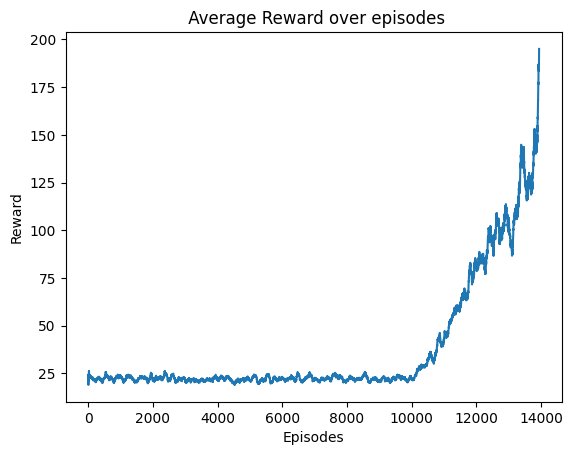

In [17]:
plt.plot(average_rew)
plt.xlabel("Episodes")
plt.ylabel("Reward")
plt.title(" Average Reward over episodes")
plt.show()